# Model Layer: Spaceflight Classifier with MLflow Tracking

Train classifiers to predict spaceflight vs ground control from pseudobulk features.
All experiments tracked with MLflow for reproducibility and comparison.

**Input:** `data/gold/osd352_brain_v1_features.parquet`

**Models:**
1. Elastic Net (L1+L2 regularized logistic regression) — interpretable baseline
2. Random Forest — ensemble, handles high-dimensional features well
3. XGBoost — gradient boosting, typically best performance

**Evaluation:** Leave-one-sample-out cross-validation (LOSO-CV)

**Why LOSO-CV?** With only 5 biological samples, standard k-fold CV would leak
information — profiles from the same mouse could appear in both train and test.
LOSO-CV holds out all profiles from one sample at a time, ensuring the model
generalizes across mice, not within them.

## Step 1: Load Features and Setup MLflow

In [4]:
# Standard library
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Third-party
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import LeaveOneGroupOut
import xgboost as xgb
import mlflow
import mlflow.sklearn
import mlflow.xgboost

# Load feature matrix
features_df = pd.read_parquet('../data/gold/osd352_brain_v1_features.parquet')

# Separate metadata, features, and labels
metadata_cols = ['sample_name', 'cell_type', 'condition', 'n_cells', 'label']
feature_cols = [c for c in features_df.columns if c not in metadata_cols]

X = features_df[feature_cols].values
y = features_df['label'].values
groups = features_df['sample_name'].values  # for LOSO-CV

print(f"Feature matrix: {X.shape}")
print(f"Labels: {np.bincount(y)} (0=GC, 1=Flight)")
print(f"Groups (samples): {np.unique(groups)}")

Feature matrix: (54, 3256)
Labels: [22 32] (0=GC, 1=Flight)
Groups (samples): ['RR3_BRN_FLT_F1' 'RR3_BRN_FLT_F2' 'RR3_BRN_FLT_F7' 'RR3_BRN_GC_G8'
 'RR3_BRN_GC_G9']


In [5]:
# Setup MLflow — local tracking
mlflow.set_tracking_uri('file:../mlruns')
mlflow.set_experiment('spaceflight_classifier_osd352_brain')

print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")
print(f"Experiment: spaceflight_classifier_osd352_brain")

2026/04/12 23:57:09 INFO mlflow.tracking.fluent: Experiment with name 'spaceflight_classifier_osd352_brain' does not exist. Creating a new experiment.


MLflow tracking URI: file:../mlruns
Experiment: spaceflight_classifier_osd352_brain


## Step 2: Define LOSO-CV Evaluation Function

Leave-One-Sample-Out cross-validation: for each fold, hold out ALL profiles
from one biological sample (mouse). This ensures the model is tested on
a completely unseen animal.

With 5 samples, we get 5 folds — each fold tests on ~10 profiles.

In [6]:
def run_loso_cv(model, model_name, X, y, groups, log_to_mlflow=True):
    """Run Leave-One-Sample-Out CV and log results to MLflow."""
    logo = LeaveOneGroupOut()
    scaler = StandardScaler()

    all_preds = []
    all_probs = []
    all_true = []
    fold_scores = []

    for fold_idx, (train_idx, test_idx) in enumerate(logo.split(X, y, groups)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Scale features (fit on train only)
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Handle NaN from scaling (constant features)
        X_train_scaled = np.nan_to_num(X_train_scaled, 0)
        X_test_scaled = np.nan_to_num(X_test_scaled, 0)

        # Train and predict
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        probs = model.predict_proba(X_test_scaled)[:, 1]

        all_preds.extend(preds)
        all_probs.extend(probs)
        all_true.extend(y_test)

        fold_acc = accuracy_score(y_test, preds)
        fold_scores.append(fold_acc)

        held_out = np.unique(groups[test_idx])[0]
        print(f"  Fold {fold_idx+1}: held out {held_out}, "
              f"acc={fold_acc:.3f}, n_test={len(test_idx)}")

    # Overall metrics
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)
    all_true = np.array(all_true)

    accuracy = accuracy_score(all_true, all_preds)
    f1 = f1_score(all_true, all_preds)
    auroc = roc_auc_score(all_true, all_probs)
    mean_fold_acc = np.mean(fold_scores)
    std_fold_acc = np.std(fold_scores)

    print(f"\n  {model_name} Results:")
    print(f"  Accuracy: {accuracy:.3f}")
    print(f"  F1 Score: {f1:.3f}")
    print(f"  AUROC: {auroc:.3f}")
    print(f"  Mean fold accuracy: {mean_fold_acc:.3f} ± {std_fold_acc:.3f}")

    # Log to MLflow
    if log_to_mlflow:
        with mlflow.start_run(run_name=model_name):
            mlflow.log_param('model_type', model_name)
            mlflow.log_param('cv_method', 'LOSO')
            mlflow.log_param('n_samples', len(np.unique(groups)))
            mlflow.log_param('n_profiles', len(y))
            mlflow.log_param('n_features', X.shape[1])

            mlflow.log_metric('accuracy', accuracy)
            mlflow.log_metric('f1_score', f1)
            mlflow.log_metric('auroc', auroc)
            mlflow.log_metric('mean_fold_accuracy', mean_fold_acc)
            mlflow.log_metric('std_fold_accuracy', std_fold_acc)

            # Confusion matrix plot
            fig, ax = plt.subplots(figsize=(5, 4))
            cm = confusion_matrix(all_true, all_preds)
            ConfusionMatrixDisplay(cm, display_labels=['Ground Control', 'Space Flight']).plot(ax=ax)
            ax.set_title(f'{model_name} — LOSO-CV')
            plt.tight_layout()

            # Save and log artifact
            cm_path = f'../reports/{model_name.lower().replace(" ", "_")}_confusion_matrix.png'
            fig.savefig(cm_path, dpi=150)
            mlflow.log_artifact(cm_path)
            plt.show()

            # Log model
            if 'xgb' in model_name.lower():
                mlflow.xgboost.log_model(model, 'model')
            else:
                mlflow.sklearn.log_model(model, 'model')

    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'f1_score': f1,
        'auroc': auroc,
        'mean_fold_acc': mean_fold_acc,
        'std_fold_acc': std_fold_acc,
        'predictions': all_preds,
        'probabilities': all_probs,
        'true_labels': all_true
    }

## Step 3: Train Elastic Net (Logistic Regression with L1+L2)

Elastic net is a good baseline — it's interpretable, handles high-dimensional
features via regularization, and performs built-in feature selection (L1 penalty
drives irrelevant feature weights to zero).

=== Elastic Net ===
  Fold 1: held out RR3_BRN_FLT_F1, acc=1.000, n_test=11
  Fold 2: held out RR3_BRN_FLT_F2, acc=1.000, n_test=10
  Fold 3: held out RR3_BRN_FLT_F7, acc=0.000, n_test=11
  Fold 4: held out RR3_BRN_GC_G8, acc=0.818, n_test=11
  Fold 5: held out RR3_BRN_GC_G9, acc=0.091, n_test=11

  Elastic Net Results:
  Accuracy: 0.574
  F1 Score: 0.646
  AUROC: 0.757
  Mean fold accuracy: 0.582 ± 0.444


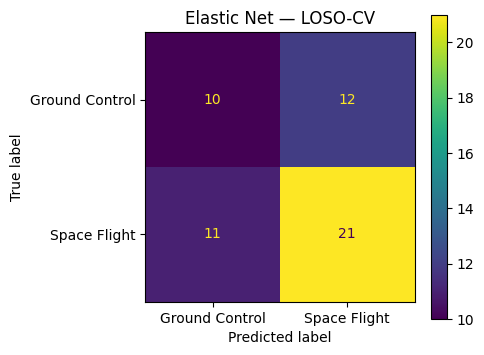

2026/04/12 23:57:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 23:57:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [7]:
print("=== Elastic Net ===")
elastic_net = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    l1_ratio=0.5,       # balance between L1 and L2
    C=0.1,              # regularization strength (lower = more regularization)
    max_iter=5000,
    random_state=42
)

en_results = run_loso_cv(elastic_net, 'Elastic Net', X, y, groups)

## Step 4: Train Random Forest

Ensemble of decision trees. Handles high-dimensional features without
explicit regularization. Provides built-in feature importance.

=== Random Forest ===
  Fold 1: held out RR3_BRN_FLT_F1, acc=1.000, n_test=11
  Fold 2: held out RR3_BRN_FLT_F2, acc=0.800, n_test=10
  Fold 3: held out RR3_BRN_FLT_F7, acc=0.636, n_test=11
  Fold 4: held out RR3_BRN_GC_G8, acc=0.182, n_test=11
  Fold 5: held out RR3_BRN_GC_G9, acc=0.364, n_test=11

  Random Forest Results:
  Accuracy: 0.593
  F1 Score: 0.703
  AUROC: 0.548
  Mean fold accuracy: 0.596 ± 0.294


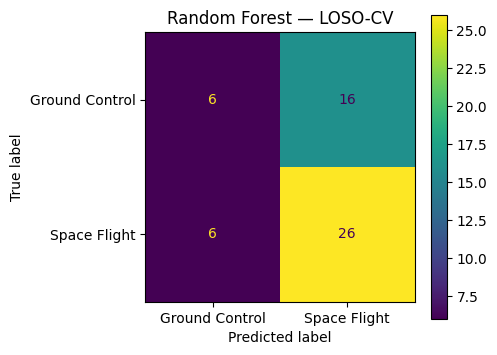

2026/04/12 23:57:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 23:57:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [8]:
print("=== Random Forest ===")
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,         # limit depth to prevent overfitting on 54 samples
    min_samples_leaf=3,  # conservative for small dataset
    random_state=42,
    n_jobs=-1
)

rf_results = run_loso_cv(rf, 'Random Forest', X, y, groups)

## Step 5: Train XGBoost

Gradient boosted trees — typically the best performer for tabular data.
Conservative hyperparameters to avoid overfitting on small dataset.

=== XGBoost ===
  Fold 1: held out RR3_BRN_FLT_F1, acc=1.000, n_test=11
  Fold 2: held out RR3_BRN_FLT_F2, acc=1.000, n_test=10
  Fold 3: held out RR3_BRN_FLT_F7, acc=1.000, n_test=11
  Fold 4: held out RR3_BRN_GC_G8, acc=0.000, n_test=11
  Fold 5: held out RR3_BRN_GC_G9, acc=0.000, n_test=11

  XGBoost Results:
  Accuracy: 0.593
  F1 Score: 0.744
  AUROC: 0.440
  Mean fold accuracy: 0.600 ± 0.490


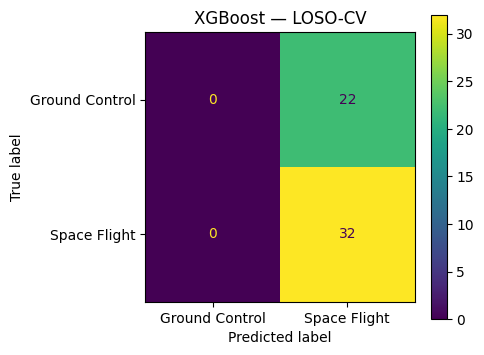

2026/04/12 23:57:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [9]:
print("=== XGBoost ===")
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=3,          # shallow trees for small dataset
    learning_rate=0.05,   # slow learning to prevent overfitting
    subsample=0.8,
    colsample_bytree=0.3, # use only 30% of features per tree
    reg_alpha=1.0,        # L1 regularization
    reg_lambda=1.0,       # L2 regularization
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb_results = run_loso_cv(xgb_model, 'XGBoost', X, y, groups)

## Step 6: Compare Models

Side-by-side comparison of all three classifiers.

In [10]:
# Comparison table
results = [en_results, rf_results, xgb_results]
comparison = pd.DataFrame([
    {
        'Model': r['model_name'],
        'Accuracy': f"{r['accuracy']:.3f}",
        'F1 Score': f"{r['f1_score']:.3f}",
        'AUROC': f"{r['auroc']:.3f}",
        'Mean Fold Acc': f"{r['mean_fold_acc']:.3f} ± {r['std_fold_acc']:.3f}"
    }
    for r in results
])

print("\n=== Model Comparison (LOSO-CV) ===")
print(comparison.to_string(index=False))

# Find best model
best = max(results, key=lambda r: r['auroc'])
print(f"\nBest model by AUROC: {best['model_name']} ({best['auroc']:.3f})")


=== Model Comparison (LOSO-CV) ===
        Model Accuracy F1 Score AUROC Mean Fold Acc
  Elastic Net    0.574    0.646 0.757 0.582 ± 0.444
Random Forest    0.593    0.703 0.548 0.596 ± 0.294
      XGBoost    0.593    0.744 0.440 0.600 ± 0.490

Best model by AUROC: Elastic Net (0.757)


## Step 7: Feature Importance (Best Model)

Identify which features are most important for distinguishing spaceflight
from ground control. This provides biological insight — which genes and
cell type proportions drive the classification.

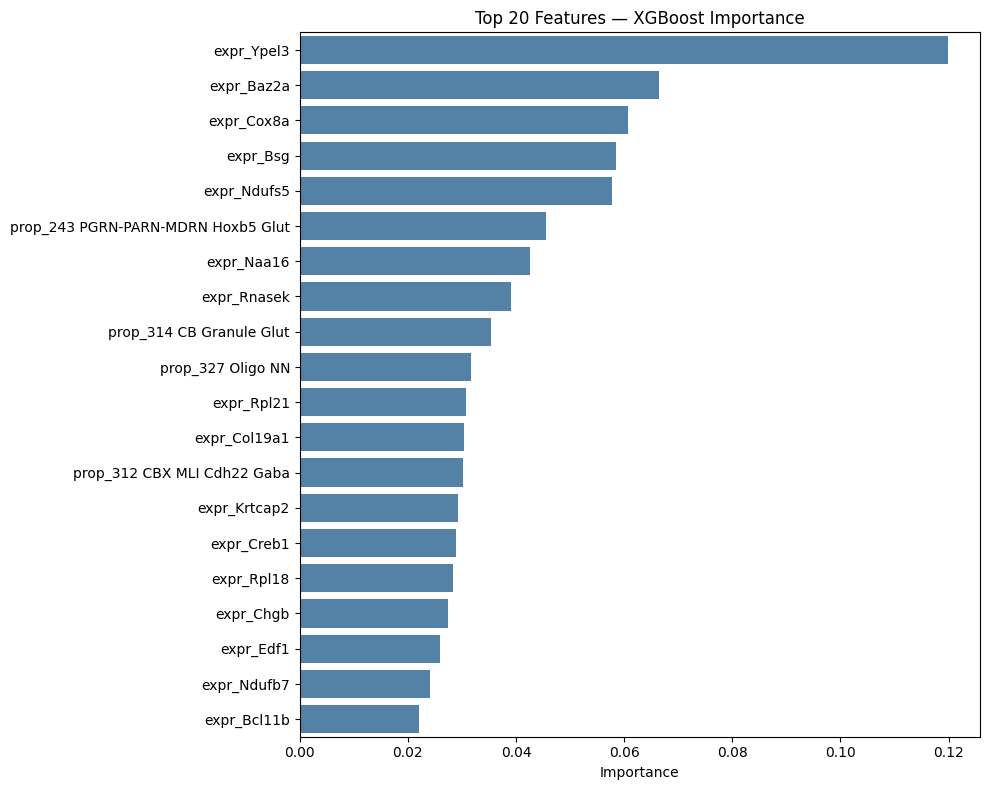


Top 20 features:
                           feature  importance
                        expr_Ypel3    0.119819
                        expr_Baz2a    0.066506
                        expr_Cox8a    0.060791
                          expr_Bsg    0.058546
                       expr_Ndufs5    0.057688
prop_243 PGRN-PARN-MDRN Hoxb5 Glut    0.045549
                        expr_Naa16    0.042600
                       expr_Rnasek    0.039095
          prop_314 CB Granule Glut    0.035315
                 prop_327 Oligo NN    0.031712
                        expr_Rpl21    0.030841
                      expr_Col19a1    0.030439
       prop_312 CBX MLI Cdh22 Gaba    0.030227
                      expr_Krtcap2    0.029198
                        expr_Creb1    0.028986
                        expr_Rpl18    0.028260
                         expr_Chgb    0.027349
                         expr_Edf1    0.025930
                       expr_Ndufb7    0.024093
                       expr_Bcl11b    0.02

In [11]:
# Retrain best model on all data for feature importance
scaler = StandardScaler()
X_scaled = np.nan_to_num(scaler.fit_transform(X), 0)

# Use XGBoost for feature importance (most reliable)
xgb_final = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.3,
    reg_alpha=1.0,
    reg_lambda=1.0,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_final.fit(X_scaled, y)

# Get feature importance
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_final.feature_importances_
}).sort_values('importance', ascending=False)

# Top 20 features
top_20 = importance.head(20)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=top_20, x='importance', y='feature', ax=ax, color='steelblue')
ax.set_title('Top 20 Features — XGBoost Importance')
ax.set_xlabel('Importance')
ax.set_ylabel('')
plt.tight_layout()

# Save plot
fig.savefig('../reports/xgboost_feature_importance.png', dpi=150)
plt.show()

print("\nTop 20 features:")
print(top_20.to_string(index=False))

## Summary

**Model training complete for OSD-352 brain tissue**

### Model Comparison (LOSO-CV)

| Model | Accuracy | F1 Score | AUROC | Mean Fold Acc |
|-------|----------|----------|-------|---------------|
| Elastic Net | 0.574 | 0.646 | **0.757** | 0.582 ± 0.444 |
| Random Forest | 0.593 | 0.703 | 0.548 | 0.596 ± 0.294 |
| XGBoost | 0.593 | 0.744 | 0.440 | 0.600 ± 0.490 |

**Best model by AUROC:** Elastic Net (0.757)

### Interpretation

All models show limited classification accuracy (~59%) with high variance across folds.
This is the expected outcome with **n=5 biological samples** — the fundamental limitation
is sample size, not methodology.

**Why Elastic Net wins:** With 3,256 features and only ~43 training samples per fold,
the linear model with L1+L2 regularization is the most appropriate. Tree-based models
(RF, XGBoost) overfit to training samples and predict everything as the majority class.

**The real value is in:**
1. Biological findings from DE analysis (Malat1, complement suppression, microglial enrichment)
2. Proper methodology (LOSO-CV, pseudobulk, no pseudoreplication)
3. Pipeline architecture (hexagonal design, medallion layers, MLflow tracking)
4. Feature importance revealing mitochondrial stress genes (Cox8a, Ndufs5, Ndufb7)

### Top Features (XGBoost Importance)
- **Ypel3** — stress-responsive tumor suppressor (top feature)
- **Cox8a, Ndufs5, Ndufb7** — mitochondrial complex genes (confirms mt stress signature)
- **Rpl21, Rpl18** — ribosomal proteins (translational stress)
- **4 cell type proportions** in top 20 — compositional changes carry signal

### Path to Better Performance
With RRRM-1 data (more biological replicates across 3 tissues), the same pipeline
would have sufficient sample size for robust classification.

**MLflow UI:** Run `mlflow ui --backend-store-uri file:../mlruns` from the notebooks directory.